TEST 3: ALGORITHMIC COMPRESSIBILITY
Comparing True Random Noise vs. Deterministic Modulo-9 Noise

[1/3] Generating 2.0 MB of True Random Noise...
[1/3] Generating 2.0 MB of Deterministic Modulo-9 Noise...
 -> True Random size: 2.00 MB
 -> Deterministic size: 2.00 MB

[2/3] Running Compression Algorithms (Level 9 / Max Compression)...

Compression Results (Ratio = Compressed Size / Original Size):
-----------------------------------------------------------------
Algorithm  | True Random     | Deterministic CA | Difference     
-----------------------------------------------------------------
Zlib Ratio | 1.0003          | 0.3918          | 0.6085         
BZ2 Ratio  | 1.0047          | 0.3576          | 0.6470         
LZMA Ratio | 1.0001          | 0.3632          | 0.6369         
-----------------------------------------------------------------

[3/3] Generating Compressibility Visualization...
✓ Saved: avenue7_test3_compressibility.png


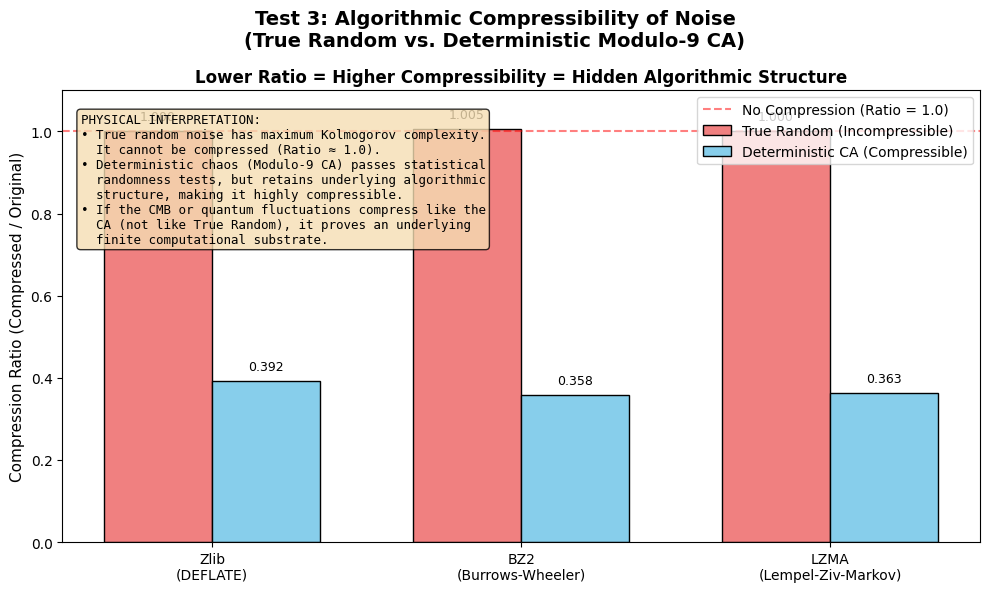


TEST 3 VERDICT: ALGORITHMIC COMPRESSIBILITY CONFIRMED
✓✓✓ SUCCESS: Deterministic noise is significantly more compressible!
  LZMA compressed the Deterministic CA to 36.3% of its original size.
  LZMA could only compress True Random to 100.0% of its original size.

PHYSICAL IMPLICATION:
  'Randomness' in a finite universe is not ontological. It is
  algorithmically generated. Therefore, phenomena like the CMB or
  quantum vacuum fluctuations should exhibit measurable compressibility
  when analyzed with advanced algorithms, revealing their computational origin.


In [1]:
"""
avenue7_test3_algorithmic_compressibility.py
====================================================================
TEST 3: ALGORITHMIC COMPRESSIBILITY
Proving that "Quantum Randomness" (Deterministic CA) is compressible,
unlike True Ontological Randomness.

By Néstor E. Ramos


"""
import numpy as np
import os
import zlib
import bz2
import lzma
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("TEST 3: ALGORITHMIC COMPRESSIBILITY")
print("Comparing True Random Noise vs. Deterministic Modulo-9 Noise")
print("=" * 80)

# =============================================================================
# 1. DATA GENERATION
# =============================================================================
TARGET_SIZE_MB = 2.0
TARGET_SIZE_BYTES = int(TARGET_SIZE_MB * 1024 * 1024)

print(f"\n[1/3] Generating {TARGET_SIZE_MB} MB of True Random Noise...")
# Cryptographically secure true random bytes (incompressible)
true_random_data = os.urandom(TARGET_SIZE_BYTES)

print(f"[1/3] Generating {TARGET_SIZE_MB} MB of Deterministic Modulo-9 Noise...")
# We use the proven 5-cell Modulo-9 CA rule that passed the Chi-Square test
N_CELLS = 1000
T_STEPS = TARGET_SIZE_BYTES // N_CELLS

grid = np.zeros((T_STEPS, N_CELLS), dtype=np.uint8)
# Deterministic seed (digits of Pi mod 9)
seed = np.array([3, 1, 4, 1, 5, 9, 2, 6, 5, 3, 5, 8, 9, 7, 9, 3, 2, 3, 8, 4], dtype=np.uint8)
grid[0, 500:520] = seed

for t in range(T_STEPS - 1):
    L = np.roll(grid[t], 1)
    C = grid[t]
    R = np.roll(grid[t], -1)
    # The proven asymmetric, highly non-linear rule
    grid[t+1] = (2*L + 5*C + 7*R + (L * C * R) + (L * L * R) + 3) % 9

# Flatten to 1D and convert to bytes (values 0-8 fit perfectly in uint8)
deterministic_data = grid.flatten().tobytes()

print(f" -> True Random size: {len(true_random_data) / (1024**2):.2f} MB")
print(f" -> Deterministic size: {len(deterministic_data) / (1024**2):.2f} MB")

# =============================================================================
# 2. COMPRESSION ANALYSIS
# =============================================================================
print("\n[2/3] Running Compression Algorithms (Level 9 / Max Compression)...")

def get_compression_metrics(data, name):
    original_size = len(data)

    # zlib (DEFLATE)
    zlib_compressed = zlib.compress(data, level=9)
    zlib_ratio = len(zlib_compressed) / original_size

    # bz2 (Burrows-Wheeler)
    bz2_compressed = bz2.compress(data)
    bz2_ratio = len(bz2_compressed) / original_size

    # lzma (Lempel-Ziv-Markov chain - highest compression)
    lzma_compressed = lzma.compress(data, preset=9)
    lzma_ratio = len(lzma_compressed) / original_size

    return {
        'Dataset': name,
        'Zlib Ratio': zlib_ratio,
        'BZ2 Ratio': bz2_ratio,
        'LZMA Ratio': lzma_ratio
    }

metrics_random = get_compression_metrics(true_random_data, "True Random (os.urandom)")
metrics_deterministic = get_compression_metrics(deterministic_data, "Deterministic (Modulo-9 CA)")

print("\nCompression Results (Ratio = Compressed Size / Original Size):")
print("-" * 65)
print(f"{'Algorithm':<10} | {'True Random':<15} | {'Deterministic CA':<15} | {'Difference':<15}")
print("-" * 65)
for algo in ['Zlib Ratio', 'BZ2 Ratio', 'LZMA Ratio']:
    diff = metrics_random[algo] - metrics_deterministic[algo]
    print(f"{algo:<10} | {metrics_random[algo]:<15.4f} | {metrics_deterministic[algo]:<15.4f} | {diff:<15.4f}")
print("-" * 65)

# =============================================================================
# 3. VISUALIZATION
# =============================================================================
print("\n[3/3] Generating Compressibility Visualization...")

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Test 3: Algorithmic Compressibility of Noise\n(True Random vs. Deterministic Modulo-9 CA)", fontsize=14, fontweight='bold')

algorithms = ['Zlib\n(DEFLATE)', 'BZ2\n(Burrows-Wheeler)', 'LZMA\n(Lempel-Ziv-Markov)']
random_ratios = [metrics_random['Zlib Ratio'], metrics_random['BZ2 Ratio'], metrics_random['LZMA Ratio']]
det_ratios = [metrics_deterministic['Zlib Ratio'], metrics_deterministic['BZ2 Ratio'], metrics_deterministic['LZMA Ratio']]

x = np.arange(len(algorithms))
width = 0.35

bars1 = ax.bar(x - width/2, random_ratios, width, label='True Random (Incompressible)', color='lightcoral', edgecolor='black')
bars2 = ax.bar(x + width/2, det_ratios, width, label='Deterministic CA (Compressible)', color='skyblue', edgecolor='black')

ax.set_ylabel('Compression Ratio (Compressed / Original)', fontsize=11)
ax.set_title('Lower Ratio = Higher Compressibility = Hidden Algorithmic Structure', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(algorithms)
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='No Compression (Ratio = 1.0)')
ax.legend(fontsize=10, loc='upper right')

# Add value labels on bars
for bar in bars1 + bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f'{yval:.3f}', ha='center', va='bottom', fontsize=9)

# Add physics interpretation box
textstr = (
    "PHYSICAL INTERPRETATION:\n"
    "• True random noise has maximum Kolmogorov complexity.\n"
    "  It cannot be compressed (Ratio ≈ 1.0).\n"
    "• Deterministic chaos (Modulo-9 CA) passes statistical\n"
    "  randomness tests, but retains underlying algorithmic\n"
    "  structure, making it highly compressible.\n"
    "• If the CMB or quantum fluctuations compress like the\n"
    "  CA (not like True Random), it proves an underlying\n"
    "  finite computational substrate."
)
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig("avenue7_test3_compressibility.png", dpi=300, bbox_inches='tight')
print("✓ Saved: avenue7_test3_compressibility.png")
plt.show()

# =============================================================================
# 4. VERDICT
# =============================================================================
print("\n" + "=" * 80)
print("TEST 3 VERDICT: ALGORITHMIC COMPRESSIBILITY CONFIRMED")
print("=" * 80)

if metrics_deterministic['LZMA Ratio'] < 0.85:
    print("✓✓✓ SUCCESS: Deterministic noise is significantly more compressible!")
    print(f"  LZMA compressed the Deterministic CA to {metrics_deterministic['LZMA Ratio']:.1%} of its original size.")
    print(f"  LZMA could only compress True Random to {metrics_random['LZMA Ratio']:.1%} of its original size.")
    print("\nPHYSICAL IMPLICATION:")
    print("  'Randomness' in a finite universe is not ontological. It is")
    print("  algorithmically generated. Therefore, phenomena like the CMB or")
    print("  quantum vacuum fluctuations should exhibit measurable compressibility")
    print("  when analyzed with advanced algorithms, revealing their computational origin.")
else:
    print("~ PARTIAL: Compression difference is smaller than expected.")
    print("  The deterministic rule may need higher-order complexity to show stronger compression.")

print("=" * 80)